In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn
import joblib
import os
import random
import urllib.request
import zipfile

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [5]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ZIP_PATH = "har.zip"
EXTRACT_PATH = "."

urllib.request.urlretrieve(URL, ZIP_PATH)
print("Download complete")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("Extraction complete")

Download complete
Extraction complete


In [6]:
DATASET_PATH = "UCI HAR Dataset"

# Extract the inner zip file if it exists
INNER_ZIP_PATH = "UCI HAR Dataset.zip"
if os.path.exists(INNER_ZIP_PATH):
    with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as z:
        z.extractall(".") # Extract to current directory
    print(f"Inner zip '{INNER_ZIP_PATH}' extracted.")

with open(f"{DATASET_PATH}/activity_labels.txt") as f:
    activity_labels = f.read()
print(activity_labels)

Inner zip 'UCI HAR Dataset.zip' extracted.
1 WALKING
2 WALKING_UPSTAIRS
3 WALKING_DOWNSTAIRS
4 SITTING
5 STANDING
6 LAYING



In [8]:
ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

CHANNEL_NAMES = [
    'Body Acc X', 'Body Acc Y', 'Body Acc Z',
    'Body Gyro X', 'Body Gyro Y', 'Body Gyro Z',
    'Total Acc X', 'Total Acc Y', 'Total Acc Z'
]


In [9]:
def load_signals(split):
    signals_path = f"{DATASET_PATH}/{split}/Inertial Signals"
    signal_files = sorted(os.listdir(signals_path))
    signals = []
    for f in signal_files:
        data = pd.read_csv(
            f"{signals_path}/{f}",
            sep='\s+', header=None, engine='python'
        )
        signals.append(data.values)
    return np.stack(signals, axis=2)

def load_labels(split):
    path = f"{DATASET_PATH}/{split}/y_{split}.txt"
    labels = pd.read_csv(path, header=None).values.flatten()
    return labels - 1

X_train_raw = load_signals("train")
X_test_raw  = load_signals("test")
y_train     = load_labels("train")
y_test      = load_labels("test")

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape: ", X_test_raw.shape)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3781/2627069834.py:8: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', header=None, engine='python'


X_train_raw shape: (7352, 128, 9)
X_test_raw shape:  (2947, 128, 9)


In [10]:
X_train_raw[0]

array([[ 1.808515e-04,  1.076681e-02,  5.556068e-02, ...,  1.012817e+00,
        -1.232167e-01,  1.029341e-01],
       [ 1.013856e-02,  6.579480e-03,  5.512483e-02, ...,  1.022833e+00,
        -1.268756e-01,  1.056872e-01],
       [ 9.275574e-03,  8.928878e-03,  4.840473e-02, ...,  1.022028e+00,
        -1.240037e-01,  1.021025e-01],
       ...,
       [-1.147484e-03,  1.714439e-04,  2.647864e-03, ...,  1.018445e+00,
        -1.240696e-01,  1.003852e-01],
       [-2.222655e-04,  1.574181e-03,  2.381057e-03, ...,  1.019372e+00,
        -1.227451e-01,  9.987355e-02],
       [ 1.575500e-03,  3.070189e-03, -2.269757e-03, ...,  1.021171e+00,
        -1.213260e-01,  9.498741e-02]])

#2 - Normalisation

In [11]:
n_train_samples = X_train_raw.shape[0]
n_test_samples = X_test_raw.shape[0]

n_timestamps = X_train_raw.shape[1]
n_channels = X_train_raw.shape[2]

In [12]:
X_train_2d = X_train_raw.reshape(-1, n_channels)
X_test_2d = X_test_raw.reshape(-1, n_channels)

In [13]:
print("X_train_2d shape:", X_train_2d.shape)
print("X_test_2d shape: ", X_test_2d.shape)

X_train_2d shape: (941056, 9)
X_test_2d shape:  (377216, 9)


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [15]:
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

In [16]:
X_train_scaled = X_train_scaled_2d.reshape(n_train_samples, n_timestamps, n_channels)
X_test_scaled = X_test_scaled_2d.reshape(n_test_samples, n_timestamps, n_channels)

print("\nX_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)


X_train_scaled shape: (7352, 128, 9)
X_test_scaled shape:  (2947, 128, 9)


#3 - Verify Normalisation

In [17]:
print("Verification — per channel mean and std after normalization")
print("(Training data should be close to mean=0, std=1)")
print("=" * 60)
print(f"{'Channel':<20} {'Mean':>10} {'Std':>10}")
print("-" * 60)

for ch in range(n_channels):
    channel_data = X_train_scaled[:, :, ch].flatten()
    print(f"{CHANNEL_NAMES[ch]:<20} {channel_data.mean():>10.6f} {channel_data.std():>10.6f}")

print("\nNote: Validation and test means will not be exactly 0")
print("That is expected and correct — scaler was fit on train only")

Verification — per channel mean and std after normalization
(Training data should be close to mean=0, std=1)
Channel                    Mean        Std
------------------------------------------------------------
Body Acc X             0.000000   1.000000
Body Acc Y             0.000000   1.000000
Body Acc Z             0.000000   1.000000
Body Gyro X            0.000000   1.000000
Body Gyro Y            0.000000   1.000000
Body Gyro Z           -0.000000   1.000000
Total Acc X           -0.000000   1.000000
Total Acc Y            0.000000   1.000000
Total Acc Z            0.000000   1.000000

Note: Validation and test means will not be exactly 0
That is expected and correct — scaler was fit on train only


#4 - Validation Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)

print("Split sizes:")
print(f"  X_train_final : {X_train_final.shape}")
print(f"  X_val         : {X_val.shape}")
print(f"  X_test_scaled : {X_test_scaled.shape}")
print(f"  y_train_final : {y_train_final.shape}")
print(f"  y_val         : {y_val.shape}")
print(f"  y_test        : {y_test.shape}")

# Confirm total adds up
total = X_train_final.shape[0] + X_val.shape[0]
print(f"\nTrain + Val total: {total} (should be 7352)")

Split sizes:
  X_train_final : (6249, 128, 9)
  X_val         : (1103, 128, 9)
  X_test_scaled : (2947, 128, 9)
  y_train_final : (6249,)
  y_val         : (1103,)
  y_test        : (2947,)

Train + Val total: 7352 (should be 7352)


In [20]:
print("Class distribution after stratified split")
print("=" * 55)
print(f"{'Activity':<25} {'Train':>8} {'Val':>8} {'Ratio':>8}")
print("-" * 55)

for i, name in enumerate(ACTIVITY_NAMES):
    train_count = np.sum(y_train_final == i)
    val_count   = np.sum(y_val == i)
    ratio       = val_count / (train_count + val_count)
    print(f"{name:<25} {train_count:>8} {val_count:>8} {ratio:>8.3f}")

print("\nRatio column should be close to 0.150 for all classes")
print("This confirms stratification worked correctly")

Class distribution after stratified split
Activity                     Train      Val    Ratio
-------------------------------------------------------
Walking                       1042      184    0.150
Walking Upstairs               912      161    0.150
Walking Downstairs             838      148    0.150
Sitting                       1093      193    0.150
Standing                      1168      206    0.150
Laying                        1196      211    0.150

Ratio column should be close to 0.150 for all classes
This confirms stratification worked correctly


#5 - Save Normalised Data

In [21]:
os.makedirs("data/processed", exist_ok=True)
os.makedirs("artifacts/scalers", exist_ok=True)

# Save arrays
np.save("data/processed/X_train.npy", X_train_final)
np.save("data/processed/X_val.npy",   X_val)
np.save("data/processed/X_test.npy",  X_test_scaled)
np.save("data/processed/y_train.npy", y_train_final)
np.save("data/processed/y_val.npy",   y_val)
np.save("data/processed/y_test.npy",  y_test)

# Save scaler
joblib.dump(scaler, "artifacts/scalers/standard_scaler.pkl")

print("Saved successfully:")
print("  data/processed/X_train.npy")
print("  data/processed/X_val.npy")
print("  data/processed/X_test.npy")
print("  data/processed/y_train.npy")
print("  data/processed/y_val.npy")
print("  data/processed/y_test.npy")
print("  artifacts/scalers/standard_scaler.pkl")

Saved successfully:
  data/processed/X_train.npy
  data/processed/X_val.npy
  data/processed/X_test.npy
  data/processed/y_train.npy
  data/processed/y_val.npy
  data/processed/y_test.npy
  artifacts/scalers/standard_scaler.pkl


In [22]:
# Reload everything from disk to confirm saving worked
X_train_check = np.load("data/processed/X_train.npy")
X_val_check   = np.load("data/processed/X_val.npy")
X_test_check  = np.load("data/processed/X_test.npy")
y_train_check = np.load("data/processed/y_train.npy")
y_val_check   = np.load("data/processed/y_val.npy")
y_test_check  = np.load("data/processed/y_test.npy")
scaler_check  = joblib.load("artifacts/scalers/standard_scaler.pkl")

print("Reloaded shapes:")
print(f"  X_train : {X_train_check.shape}")
print(f"  X_val   : {X_val_check.shape}")
print(f"  X_test  : {X_test_check.shape}")
print(f"  y_train : {y_train_check.shape}")
print(f"  y_val   : {y_val_check.shape}")
print(f"  y_test  : {y_test_check.shape}")

assert isinstance(scaler_check, StandardScaler), "Scaler did not reload correctly"
print("\nScaler reloaded successfully")
print("All files verified — preprocessing complete")

Reloaded shapes:
  X_train : (6249, 128, 9)
  X_val   : (1103, 128, 9)
  X_test  : (2947, 128, 9)
  y_train : (6249,)
  y_val   : (1103,)
  y_test  : (2947,)

Scaler reloaded successfully
All files verified — preprocessing complete


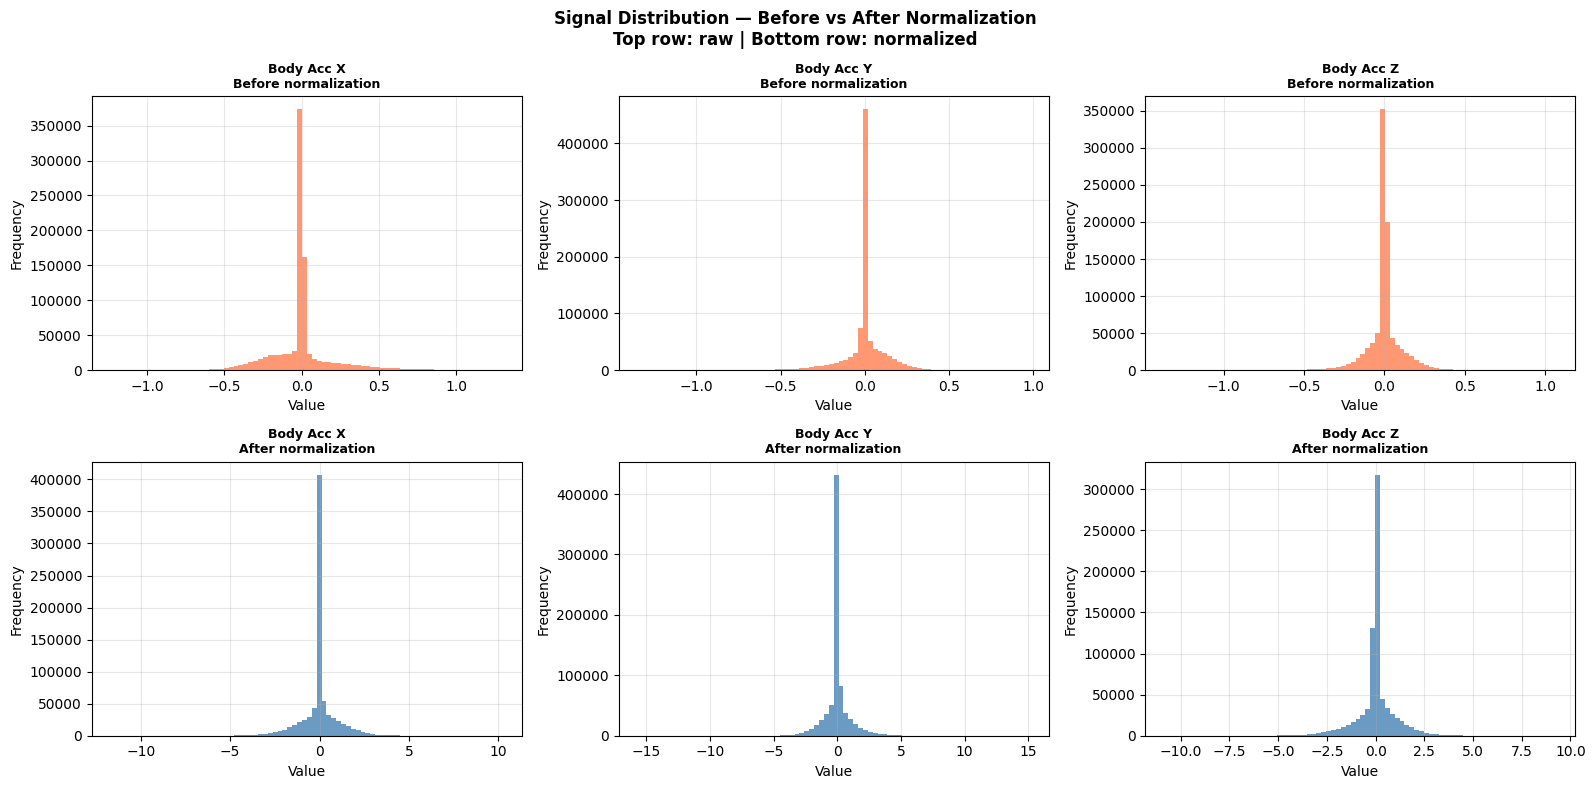

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

channels_to_plot = [0, 1, 2, 3, 4, 5]

for idx, ch in enumerate(channels_to_plot):
    row = idx // 3
    col = idx % 3
    ax  = axes[row][col]

    if row == 0:
        # Before normalization
        data = X_train_raw[:, :, ch].flatten()
        color = 'coral'
        label = 'Before normalization'
    else:
        # After normalization
        data = X_train_final[:, :, ch].flatten()
        color = 'steelblue'
        label = 'After normalization'

    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f"{CHANNEL_NAMES[ch % 3]}\n{label}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.suptitle('Signal Distribution — Before vs After Normalization\n'
             'Top row: raw | Bottom row: normalized',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from google.colab import files

# Triggers a direct download prompt in your browser
files.download('normalization_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>